<a href="https://colab.research.google.com/github/kcf1/fina4359-quant-trading/blob/asm1/fina4359_asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q3. Sleuthing via covariances and the basics of performance benchmarking

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import yfinance as yf

## Import macro return data
**CS Global Macro Index at 2x Vol Net of 95 bps**

In [ ]:
# Read 'CS Global Macro Index at 2x Vol Net of 95 bps' data.
ret = pd.read_excel('macro_return.xlsx',index_col=0)
# Convert the index to datetime
ret.index = pd.to_datetime(ret.index)
# Convert return data to float.
ret = ret.iloc[:,0].astype(float)


Samples 285 months

Annulized
Mean = 18.16%
Std  = 13.38%
Skew = -0.02
SR   = 1.36



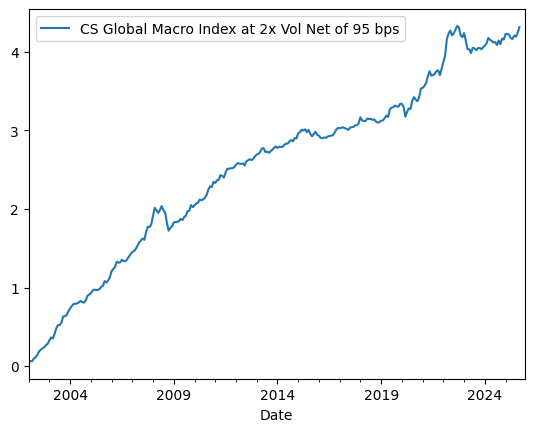

In [ ]:
# Annualized mean
m = ret.mean() * 12
# Annualized volatility
s = ret.std() * 12 ** 0.5
# Annualized Sharpe Ratio
sr = m/s
# Monthly skewness
sk = ret.skew()
# Print summary statistics
print(f'''
Samples {ret.count()} months

Annulized
Mean = {m:.2%}
Std  = {s:.2%}
Skew = {sk:.2f}
SR   = {sr:.2f}
''')
# Plot the cumulative sum of the returns.
ret.cumsum().plot()
plt.legend(['CS Global Macro Index at 2x Vol Net of 95 bps'])

## FF5 Benchmark
Conceptually, not a good benchmark:
- Macro invests in all asset classes (incl. fx, rates, commods, etc.) across regions, while FF5 only covers US equity factors
- FF5 might explain partially, as US equities is in fund's investment universe
---
Reasonable benchmark (alpha on FF5 adds uncorrelated return to their portfolio):
- US pension that primarily invest in US equity
- US big corp that are sensitive to US market cycles (high beta)
---
Inappropriate benchmark:
- Relative performance to macro peers
- Investors with access to global markets (not only US)

In [ ]:
# Fetch Fama-French 5 factors (2x3 daily breakdown) from Kenneth French's data library.
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
# Convert percentage returns to decimal form
ff5 = ff5 / 100
# Convert the default PeriodIndex to Timestamp and shift to month-end date (e.g., 2000-01-31)
ff5.index = ff5.index.to_timestamp() + pd.offsets.MonthEnd(0)

/tmp/ipykernel_31766/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
/tmp/ipykernel_31766/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]


In [ ]:
# Create a FF5 regression DataFrame.
reg_df = ff5.copy()
# Get excess return of the macro index by subtracting the risk-free rate.
reg_df['Macro-RF'] = ret - reg_df['RF']
# Drop missing values
reg_df.dropna(inplace=True)

As expected, not a good benchmark:
- FF5 factors did not explained much of the return, resulting in significantly high alpha
- Only US market factor is significant, beta ~0.24, except that HML has a relative small p-value (still insignificant), fund might have some value play
- R^2 is only 10% (90% left unexplained), FF5 failed to track the index properly

In [ ]:
# Target is the excess return.
y = reg_df['Macro-RF']
# Factors are FF5
x = reg_df.drop(columns=['RF','Macro-RF'])

In [ ]:
model = sm.OLS(y,sm.add_constant(x)).fit()
# Annualized alpha by multiplying 12.
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 13.90%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.357
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.31e-05
Time:                        18:55:45   Log-Likelihood:                 536.60
No. Observations:                 284   AIC:                            -1061.
Df Residuals:                     278   BIC:                            -1039.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0116      0.002      5.060      0.000       0.007       0.016
Mkt-RF         0.2396      0.055      4.382      0.000       0.132       0.347
SMB           -0.0036      0.095     -0.038      0.970      -0.191       0.184
HML            0.1321      0.092      1.429      0.154      -0.050       0.314
RMW            0.0155      0.113      0.137      0.891      -0.207       0.238
CMA            0.1562      0.138      1.134      0.258      -0.115       0.427
==============================================================================
Omnibus:                       29.919   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.512
Skew:                           0.247   Prob(JB):                     3.37e-28
Kurtosis:                       6.232   Cond. No.                         69.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Custom benchmark
Factors:
- **Trend** - Bloomberg equal risk trend index
- **Equity Market** - AQR century of factor premia
- **Commodities Market** - AQR century of factor premia
- **US Stock Value** - AQR century of factor premia

In [ ]:
# Load custom factors.
fret = pd.read_excel('custom_factors.xlsx',index_col=0)

In [ ]:
# Add risk-free rate to DataFrame
fret['RF'] = ff5['RF']
fret.dropna(inplace=True)

In [ ]:
# Create a custom benchmark regression DataFrame.
reg_df = fret.copy()
# Get excess return of the macro index by subtracting the risk-free rate.
reg_df['Macro-RF'] = ret - reg_df['RF']
# Drop missing values
reg_df.dropna(inplace=True)

About half of the return is replicated with the custom model
- R^2 shows 48%
- All loadings are significant, by selecting factors from the pool
- The benchmark consists of global equity, commodities, covering macro investment universe, and a trend factor that captures the common macro used strategy
- R^2 improved 38% relative to FF5, improvements come from loading **Trend** and **Commodities**, in addition to **Equity** and **Value**

In [ ]:
# Target is the excess return.
y = reg_df['Macro-RF']
# Factors are customed
x = reg_df.drop(columns=['RF','Macro-RF'])

In [ ]:
model = sm.OLS(y,sm.add_constant(x)).fit()
# Annualized alpha by multiplying 12.
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 8.16%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     44.35
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           2.45e-26
Time:                        20:00:55   Log-Likelihood:                 410.92
No. Observations:                 197   AIC:                            -811.8
Df Residuals:                     192   BIC:                            -795.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
const                                                       0.0068      0.002      3.065      0.002       0.002       0.011
BBG Multiasset Equal Risk Trend (BSLXAT Index)              2.3313      0.308      7.560      0.000       1.723       2.940
Equity indices Market (AQR Century of Factor Premia)        0.1177      0.062      1.903      0.059      -0.004       0.240
Commodities Market (AQR Century of Factor Premia)           0.4754      0.056      8.501      0.000       0.365       0.586
US Stock Selection Value (AQR Century of Factor Premia)     0.1447      0.062      2.348      0.020       0.023       0.266
==============================================================================
Omnibus:                       14.162   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               40.934
Skew:                          -0.016   Prob(JB):                     1.29e-09
Kurtosis:                       5.233   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Rolling 5-year regression R^2:
- The plot showed that the factor explainability is worst in 2014-2018, dropped from 60% to 30%, possibly some non-factor based trades during the period
- Except the above mentioned period, risk premia still contribute 2/3 of the return
- A premia explanation can be drawn for **Commodities** factor, producers pay a premium (bawardation futures) to hedge the risk, and transfer to sepculators <br>
(**In Treatise on Money, Keynes**)


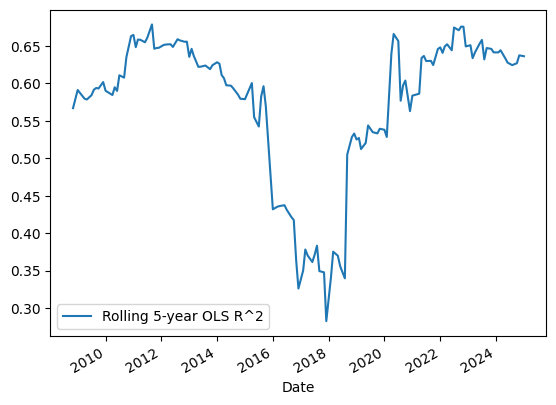

In [ ]:
from statsmodels.regression.rolling import RollingOLS
# Uses a 5-year (60-month) rolling window to capture time-varying factor exposures and model fit.
rols = RollingOLS(y,sm.add_constant(x),window=12*5).fit()
# Plot the rolling R-squared values to visualize model explanatory power over time.
rols.rsquared.plot()
plt.legend(['Rolling 5-year OLS R^2'])

Replicating portfolio tracks reasonably well in backtest
- Despite that monthly tracking error 3.01%, correlation achieved 69%, and terminal wealth is similar


Tracking error (monthly) 3.01%
Corr 69.30%



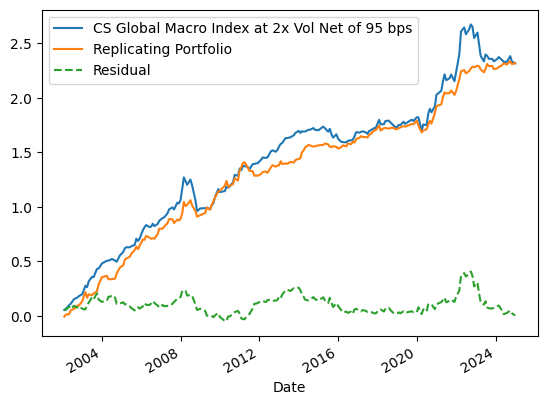

In [ ]:
# Generate in-sample replicating portfolio return (yh)
yh = model.predict(sm.add_constant(x))
# Calculate residuals (tracking error components) as actual excess returns minus replicating return.
res = y - yh
# Compute monthly tracking error as the standard deviation of residuals.
err = res.std()
print(f'''
Tracking error (monthly) {err:.2%}
Corr {y.corr(yh):.2%}
''')

# Plot cumulative sum trajectories to visualize long-term performance attribution.
y.cumsum().plot()
yh.cumsum().plot()
res.cumsum().plot(linestyle='--')
plt.legend(['CS Global Macro Index at 2x Vol Net of 95 bps','Replicating Portfolio','Residual'])